In [1]:
import tensorflow as tf
import numpy as np

In [2]:
data = np.loadtxt('./data/data-03-diabetes.csv', delimiter=',', dtype=np.float32)

x_data = data[:, 0:-1] # 학습 데이터, 처음 부터 마지막 데이터 직전까지 정답 데이터제외
y_data = data[:, [-1]] # 정답 데이터

In [3]:
print(x_data.shape, y_data.shape)

(759, 8) (759, 1)


In [5]:
print(x_data)
print(y_data)

# print(x_data, 'x_data shape:', x_data.shape)
# print(y_data, 'y_data shape:', y_data.shape)

[[-0.294118    0.487437    0.180328   ...  0.00149028 -0.53117
  -0.0333333 ]
 [-0.882353   -0.145729    0.0819672  ... -0.207153   -0.766866
  -0.666667  ]
 [-0.0588235   0.839196    0.0491803  ... -0.305514   -0.492741
  -0.633333  ]
 ...
 [-0.411765    0.21608     0.180328   ... -0.219076   -0.857387
  -0.7       ]
 [-0.882353    0.266332   -0.0163934  ... -0.102832   -0.768574
  -0.133333  ]
 [-0.882353   -0.0653266   0.147541   ... -0.0938897  -0.797609
  -0.933333  ]]
[[0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]

In [6]:
# tensorflow를 이용한 신경망 구성
model = tf.keras.Sequential()

In [ ]:
# model.add(tf.keras.Input(shape=(8,)))
# 범용적으로 동작
# 입력 레이어 추가
model.add(tf.keras.Input(shape=(x_data.shape[1], ))) # x_data.shape[1]  컬럼의 갯수를 열의 값으로 셋팅

# 출력 레이어 추가
model.add(tf.keras.layers.Dense(units=y_data.shape[1], activation='sigmoid'))  # units=1 출력은 1개, 클래스의 갯수에 따라 바뀜(unit=y_data.shape()), y_data 갯수만큼 자동으로 셋팅



In [9]:
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit 메소드로 트레이닝
loss = model.fit(x_data, y_data, epochs=500) # verbose=0 학습 시 결과 상태 미 출력
# loss = model.fit(x_data, y_data, epochs=500, verbose=0) # verbose=0 학습 시 결과 상태 미 출력

In [12]:
print('Accuracy:{0}'.format(loss.history['accuracy'][-1]))

Accuracy:0.7733860611915588


In [14]:
weights = model.layers[0].get_weights()
print(weights)

[array([[-0.8241188 ],
       [-2.862044  ],
       [ 0.13941412],
       [-0.6449731 ],
       [-0.3672437 ],
       [-1.8976103 ],
       [-0.8991732 ],
       [-0.14253528]], dtype=float32), array([0.03423865], dtype=float32)]


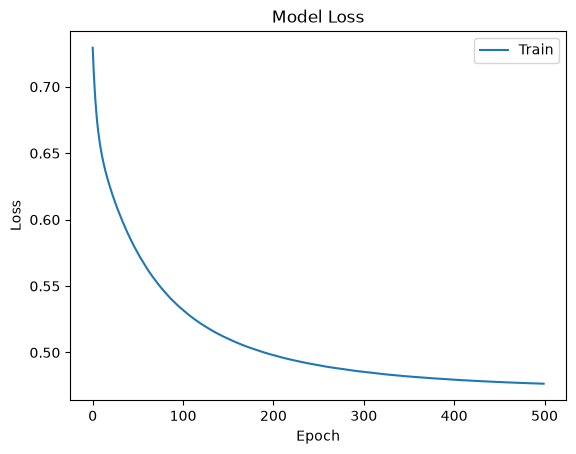

In [ ]:
# loss 값의 시각화
import matplotlib.pyplot as plt

plt.plot(loss.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train'], loc='upper right')
plt.show()
